In [1]:
import numpy as np
import matplotlib.pyplot as plt

from slmsuite.hardware.slms.simulated import SimulatedSLM
from slmsuite.hardware.cameras.simulated import SimulatedCamera
from slmsuite.hardware.cameraslms import FourierSLM
from slmsuite.holography.toolbox.phase import zernike_sum
from slmsuite.holography.toolbox.phase import zernike

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


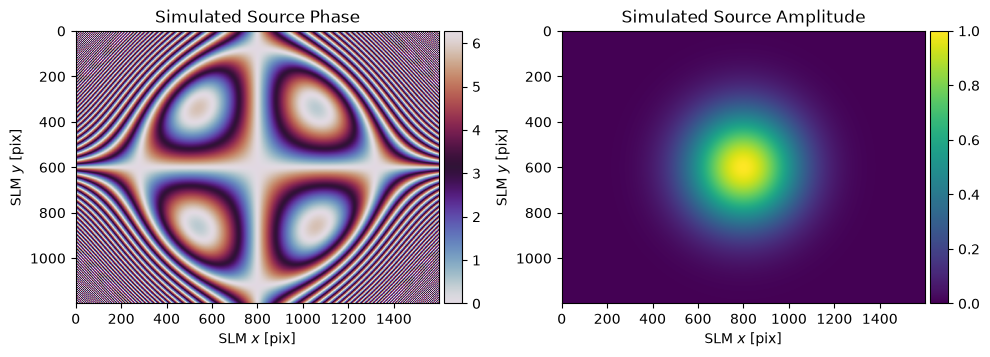

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\hardware\cameras\camera.py:444: UserWarning: 'camera' _get_image_hw() failed 5 times before quitting.
  warnings.warn(f"'{self.name}' _get_image_hw() failed {failures} times before quitting.")


{'M': array([[9250.,    0.],
        [   0., 9250.]]),
 'b': array([[512.],
        [512.]]),
 'a': array([[0],
        [0]]),
 '__version__': '0.4.1',
 '__time__': '2026-08-20 18:18:01.226125',
 '__timestamp__': 1787246281.226125,
 '__meta__': {'__class__': '<slmsuite.hardware.cameraslms.FourierSLM object at 0x00000180000D1CA0>',
  'name': 'camera-SLM',
  'cam': {'__class__': '<slmsuite.hardware.cameras.simulated.SimulatedCamera object at 0x00000180013B5520>',
   'name': 'camera',
   'shape': (1024, 1024),
   'bitdepth': 8,
   'bitresolution': 256,
   'pitch_um': array([4., 4.]),
   'exposure_s': 1,
   'exposure_bounds_s': None,
   'averaging': None,
   'hdr': None,
   'woi': (0, 1024, 0, 1024),
   'default_shape': (1024, 1024)},
  'slm': {'__class__': '<slmsuite.hardware.slms.simulated.SimulatedSLM object at 0x0000018071DE1160>',
   'name': 'SLM',
   'shape': (1200, 1600),
   'bitdepth': 8,
   'bitresolution': 256,
   'pitch_um': array([8., 8.]),
   'pitch': array([8., 8.]),
   'sett

In [2]:
# Make the SLM and camera.
slm = SimulatedSLM((1600, 1200), pitch_um=(8,8))
#phase_aberration = 0 * np.pi * zernike(slm, 4, 1)

phase_aberration = zernike_sum(
    grid=slm,
    indices= [11],
    weights = [
        12.0,
    ],
    aperture=None,
    use_mask=False,
)

slm.set_source_analytic(                        # Program the virtual source.
    fit_function="gaussian2d",
    units="mm",
    wx=1.4,
    wy=1.4,
    x0=0.0,
    y0=0.0,
    a=1.0,
    c=0.0,
    phase_offset=phase_aberration,
    sim=True
)
slm.plot_source(sim=True)

slm.set_source_analytic(sim=False)

cam = SimulatedCamera(slm, (1024, 1024), pitch_um=(4,4), gain=200)

# Tie the camera and SLM together with an analytic calibration.
fs = FourierSLM(cam, slm)
M, b = fs.fourier_calibration_build(
    f_eff=37000.,                              # f_eff of 80000 wavelengths or 80 mm with the default 1 um wavelength
    #theta=5 * np.pi / 180,
)
cam.set_affine(M, b)
fs.fourier_calibrate_analytic(M, b)

In [3]:
cam.set_exposure(1e-1)

0.1

In [4]:
fs.get_farfield_spot_size(basis='ij')

array([[3.85416667],
       [3.85416667]])

In [5]:
if "phase" in slm.source: del slm.source["phase"]
if "wavefront_superpixel" in fs.calibrations: del fs.calibrations["wavefront_superpixel"]
if "wavefront_zernike" in fs.calibrations: del fs.calibrations["wavefront_zernike"]

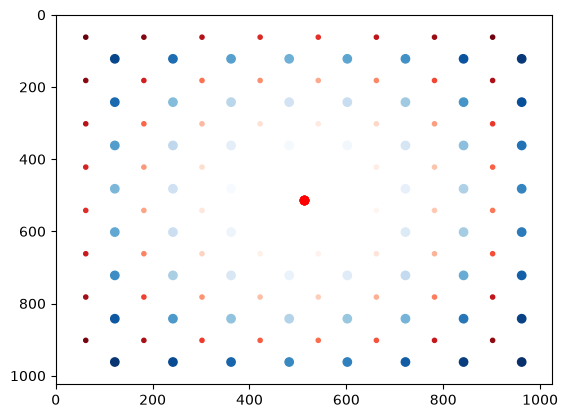

In [6]:
points_ij = fs.wavefront_calibration_points(pitch=128, plot=True)

In [7]:
from slmsuite.holography.toolbox import convert_vector

points_zernike = convert_vector(
    points_ij,
    from_units="ij",
    to_units="zernike",
    hardware=fs
)

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\algorithms\_hologram.py:766: RuntimeWarning: divide by zero encountered in scalar divide
  self.target *= 1 / Hologram._norm(self.target)


optimize_weights:   0%|          | 0/10 [00:00<?, ?it/s]

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\hardware\cameraslms.py:1961: UserWarning: Image might become overexposed during optimization (133/255).
  warnings.warn(


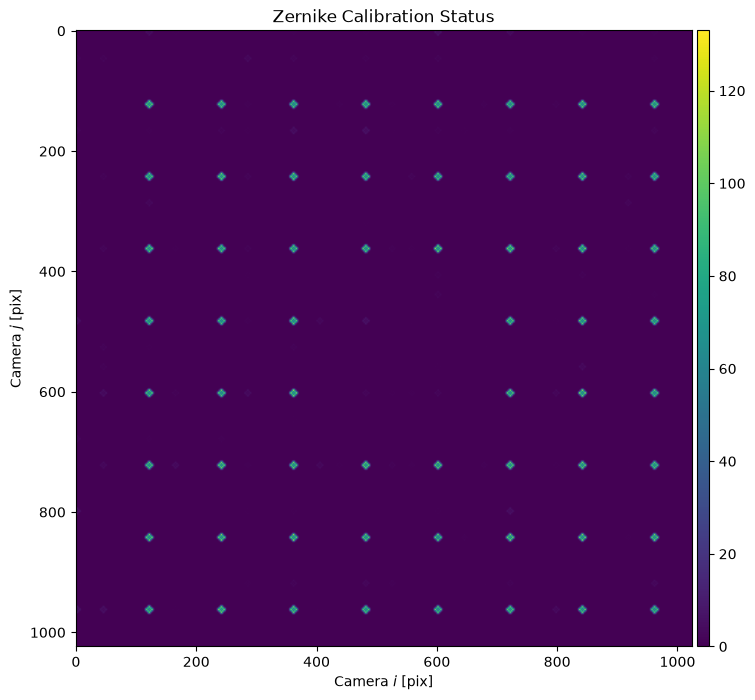

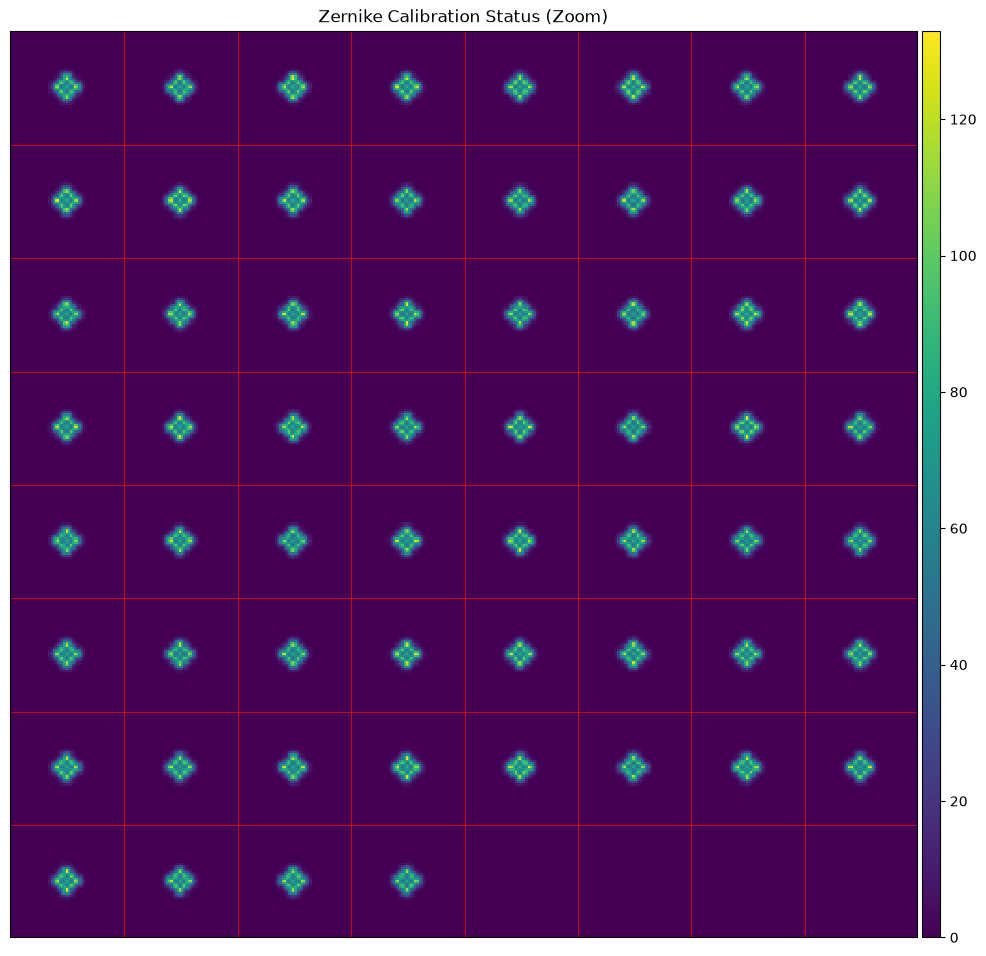

In [8]:
fs.wavefront_calibrate_zernike(
    points_zernike,
    zernike_indices=[1, 2, 4],
    perturbation=0,
    plot=2
)

In [9]:
fs.wavefront_calibrate_zernike(
    points_zernike,
    zernike_indices=[1, 2, 4],
    perturbation=np.linspace(
        0.5*np.pi,
        1.5*np.pi,
         5
    ),
    global_correction=True,
    plot=2
)

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\algorithms\_hologram.py:766: RuntimeWarning: divide by zero encountered in scalar divide
  self.target *= 1 / Hologram._norm(self.target)


KeyboardInterrupt: 

c:\Users\Xander\Documents\Code\slm\.venv\Lib\site-packages\slmsuite\holography\algorithms\_hologram.py:766: RuntimeWarning: divide by zero encountered in scalar divide
  self.target *= 1 / Hologram._norm(self.target)


optimize_weights:   0%|          | 0/10 [00:00<?, ?it/s]

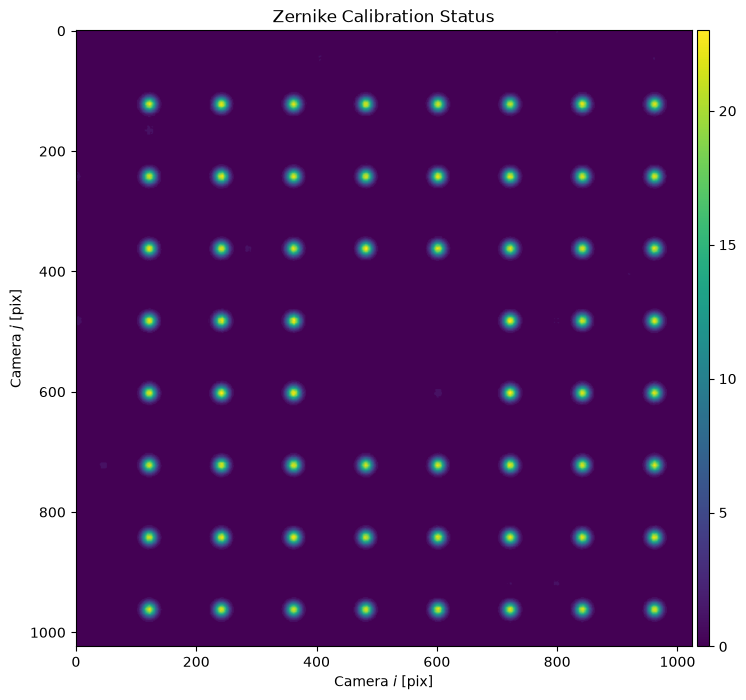

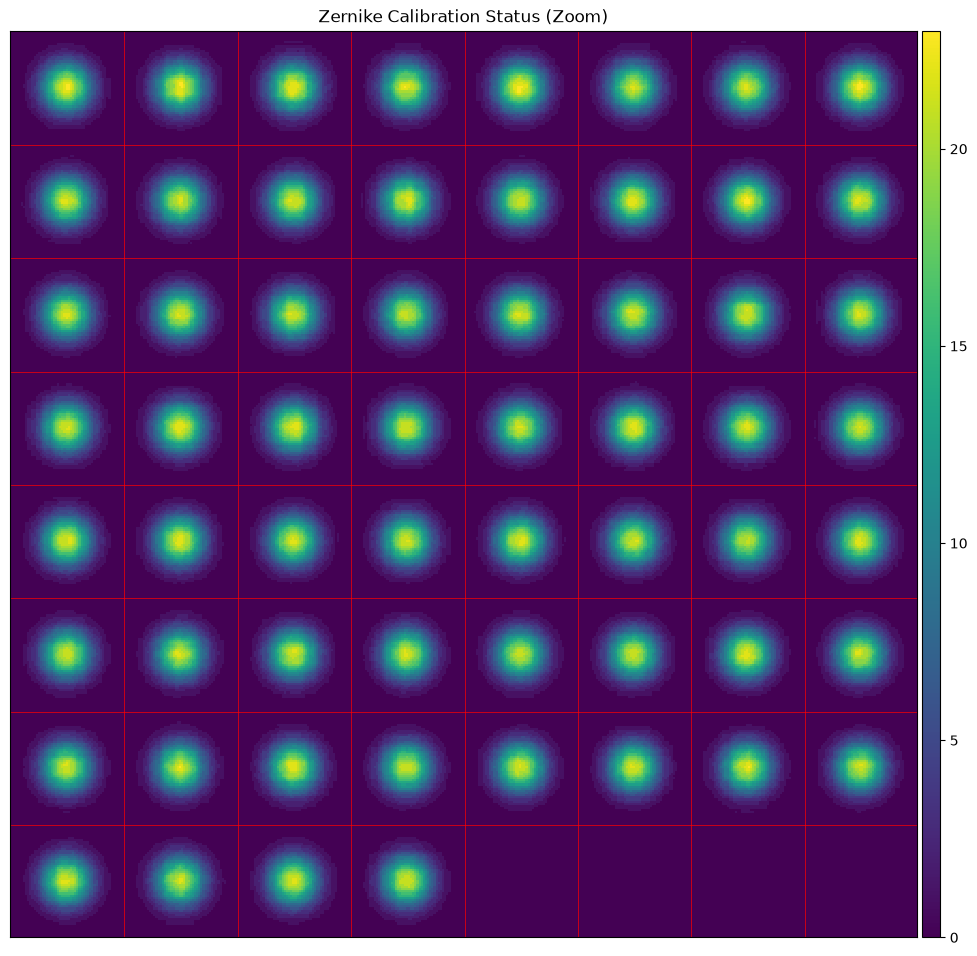

In [ ]:
fs.wavefront_calibrate_zernike(
    points_zernike,
    zernike_indices=[1, 2, 4],
    perturbation=0,
    plot=2
)